In [ ]:
import os
import openslide
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import timm
import networkx as nx

from tqdm import tqdm
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# =========================================
# 1. PATCH EXTRACTION
# =========================================

def extract_patches(slide_path, patch_size=224, stride=224, max_patches=300):
    slide = openslide.OpenSlide(slide_path)
    W, H = slide.dimensions

    patches, coords = [], []

    for x in range(0, W, stride):
        for y in range(0, H, stride):

            patch = slide.read_region((x, y), 0, (patch_size, patch_size))
            patch = np.array(patch)[:, :, :3]

            if patch.mean() > 220:
                continue

            patches.append(patch)
            coords.append((x, y))

            if len(patches) >= max_patches:
                return np.array(patches), np.array(coords)

    return np.array(patches), np.array(coords)

# =========================================
# 2. FEATURE EXTRACTION (ViT)
# =========================================

vit = timm.create_model('vit_base_patch16_224', pretrained=True)
vit.head = nn.Identity()
vit = vit.to(device)
vit.eval()

def extract_features(patches):

    patches_t = torch.tensor(patches / 255.0).permute(0,3,1,2).float()

    feats = []
    with torch.no_grad():
        for i in range(0, len(patches_t), 32):
            batch = patches_t[i:i+32].to(device)
            f = vit.forward_features(batch)
            f = f.mean(dim=1)
            feats.append(f.cpu())

    return torch.cat(feats)

# =========================================
# 3. GRAPH + PAGERANK
# =========================================

def build_graph(coords, k=6):
    return kneighbors_graph(coords, k, mode='distance')

def compute_pagerank(A):
    G = nx.from_scipy_sparse_array(A)
    pr = nx.pagerank(G)
    return np.array([pr[i] for i in range(len(pr))])

# =========================================
# 4. GNN MODEL
# =========================================

class PageRankGNN(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.gat = GATConv(in_dim, 128, heads=4)
        self.fc = nn.Linear(128*4, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index, pr):

        x = self.gat(x, edge_index)
        x = self.dropout(x)

        pr = (pr - pr.mean()) / (pr.std() + 1e-6)
        x = x + 0.1 * pr.unsqueeze(1) * x

        out = torch.sigmoid(self.fc(x)).squeeze()

        return out  # patch-level predictions

# =========================================
# 5. PROCESS SLIDE → GRAPH DATA
# =========================================

def process_slide(path, label):

    patches, coords = extract_patches(path)
    if len(patches) == 0:
        return None

    feats = extract_features(patches)
    A = build_graph(coords)
    pr = compute_pagerank(A)

    edge_index = np.vstack(A.nonzero())

    data = Data(
        x=feats,
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor([label]).float()
    )

    data.pr = torch.tensor(pr).float()
    data.coords = coords
    data.path = path

    return data

# =========================================
# 6. LOAD DATASET (YOUR 10 SLIDES)
# =========================================

def load_dataset(csv_path, img_dir, max_slides=30):

    df = pd.read_csv(csv_path)

    data_list = []

    for i in tqdm(range(max_slides)):
        row = df.iloc[i]

        slide_id = row['image_id']
        label = 1 if row['isup_grade'] > 0 else 0

        path = os.path.join(img_dir, slide_id + ".tiff")

        data = process_slide(path, label)

        if data is not None:
            data_list.append(data)

    return data_list

# =========================================
# 7. TRAIN
# =========================================

def train(model, train_data, test_data):

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCELoss()

    for epoch in range(50):

        model.train()
        total_loss = 0

        for data in train_data:

            data = data.to(device)
            data.pr = data.pr.to(device)

            optimizer.zero_grad()

            patch_preds = model(data.x, data.edge_index, data.pr)

            slide_pred = patch_preds.mean().unsqueeze(0)
            target = data.y.view_as(slide_pred)

            loss = criterion(slide_pred, target)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch}, Loss {total_loss:.4f}")

        evaluate(model, test_data)

# =========================================
# 8. EVALUATION
# =========================================

def evaluate(model, data_list):

    model.eval()

    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for data in data_list:

            data = data.to(device)
            data.pr = data.pr.to(device)

            patch_preds = model(data.x, data.edge_index, data.pr)

            slide_pred = patch_preds.mean().item()

            y_true.append(data.y.item())
            y_prob.append(slide_pred)
            y_pred.append(1 if slide_pred > 0.5 else 0)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print(f"Accuracy: {acc}, AUC: {auc}")

# =========================================
# 9. MAIN
# =========================================

def main():
    cwd = os.getcwd()
    candidates = [
        os.path.abspath(os.path.join(cwd, "data", "panda")),
        os.path.abspath(os.path.join(cwd, "..", "data", "panda")),
        os.path.abspath(os.path.join(cwd, "..", "..", "data", "panda")),
    ]

    base_dir = next((p for p in candidates if os.path.isdir(p)), None)
    if base_dir is None:
        raise FileNotFoundError(
            f"Could not find data/panda from cwd={cwd}. Tried: {candidates}"
        )

    csv_path = os.path.join(base_dir, "train.csv")
    img_dir = os.path.join(base_dir, "train_images")

    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"Missing CSV file: {csv_path}")
    if not os.path.isdir(img_dir):
        raise FileNotFoundError(f"Missing image directory: {img_dir}")

    data_list = load_dataset(csv_path, img_dir, max_slides=30)
    if len(data_list) < 2:
        raise RuntimeError(
            f"Loaded {len(data_list)} slides. Need at least 2 valid slides for train/test split."
        )

    from sklearn.model_selection import train_test_split

    labels = [d.y.item() for d in data_list]

    train_data, test_data = train_test_split(
        data_list,
        test_size=0.3,
        stratify=labels
    )
    
    model = PageRankGNN(768).to(device)

    train(model, train_data, test_data)

    return model, test_data


if __name__ == "__main__":
    model, test_data = main()

/home/sahil-narkhede/Desktop/Me/SEM6/cv/OncoPRISM-Prototype/onco-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 30/30 [47:22<00:00, 94.74s/it] 


Epoch 0, Loss 16.3012
Accuracy: 0.7777777777777778, AUC: 0.21428571428571427
Epoch 1, Loss 11.3086
Accuracy: 0.7777777777777778, AUC: 0.6428571428571428
Epoch 2, Loss 10.8783
Accuracy: 0.8888888888888888, AUC: 0.7142857142857143
Epoch 3, Loss 11.1242
Accuracy: 0.7777777777777778, AUC: 0.7142857142857143
Epoch 4, Loss 10.5575
Accuracy: 0.8888888888888888, AUC: 0.7857142857142857
Epoch 5, Loss 10.6021
Accuracy: 0.8888888888888888, AUC: 0.7857142857142857
Epoch 6, Loss 10.1455
Accuracy: 0.8888888888888888, AUC: 0.7857142857142857
Epoch 7, Loss 10.0004
Accuracy: 0.8888888888888888, AUC: 0.7857142857142857
Epoch 8, Loss 9.6765
Accuracy: 0.7777777777777778, AUC: 0.7857142857142857
Epoch 9, Loss 9.5736
Accuracy: 0.7777777777777778, AUC: 0.8571428571428572
Epoch 10, Loss 9.0800
Accuracy: 0.7777777777777778, AUC: 0.8571428571428572
Epoch 11, Loss 8.9369
Accuracy: 0.7777777777777778, AUC: 0.8571428571428571
Epoch 12, Loss 8.5988
Accuracy: 0.8888888888888888, AUC: 0.8571428571428571
Epoch 13, Los

In [3]:
# Save a kernel snapshot so you can reload later without retraining
snapshot_dir = "cache_snapshot"
os.makedirs(snapshot_dir, exist_ok=True)

checkpoint_path = os.path.join(snapshot_dir, "training_snapshot.pt")
snapshot = {}

# Save model weights (enough to restore trained model)
if "model" in globals():
    snapshot["model_state_dict"] = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    snapshot["model_class"] = model.__class__.__name__

# Save graph datasets already in memory (train/test/full if they exist)
for var_name in ["train_data", "test_data", "data_list"]:
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, list) and (len(obj) == 0 or isinstance(obj[0], Data)):
            snapshot[var_name] = [d.cpu() for d in obj]

# Optional metadata
snapshot["device_when_saved"] = device

torch.save(snapshot, checkpoint_path)
print(f"Saved snapshot to: {checkpoint_path}")
print(f"Saved keys: {list(snapshot.keys())}")

Saved snapshot to: cache_snapshot/training_snapshot.pt
Saved keys: ['model_state_dict', 'model_class', 'test_data', 'device_when_saved']


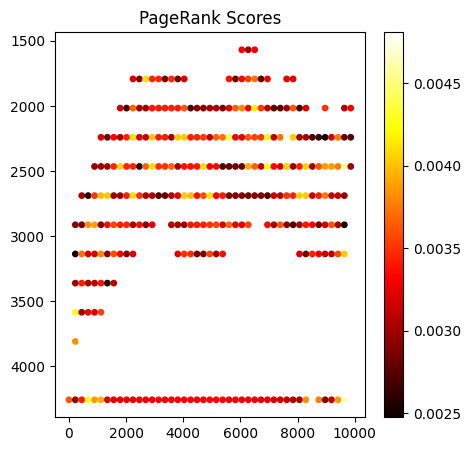

In [5]:
def plot_heatmap(coords, values, title):

    import matplotlib.pyplot as plt

    x = [c[0] for c in coords]
    y = [c[1] for c in coords]

    plt.figure(figsize=(5,5))
    plt.scatter(x, y, c=values, cmap='hot', s=15)
    plt.colorbar()
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()
    
plot_heatmap(test_data[0].coords, test_data[0].pr, "PageRank Scores")

/tmp/ipykernel_139347/3834052165.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  combined_overlay = create_overlay(pr * preds)


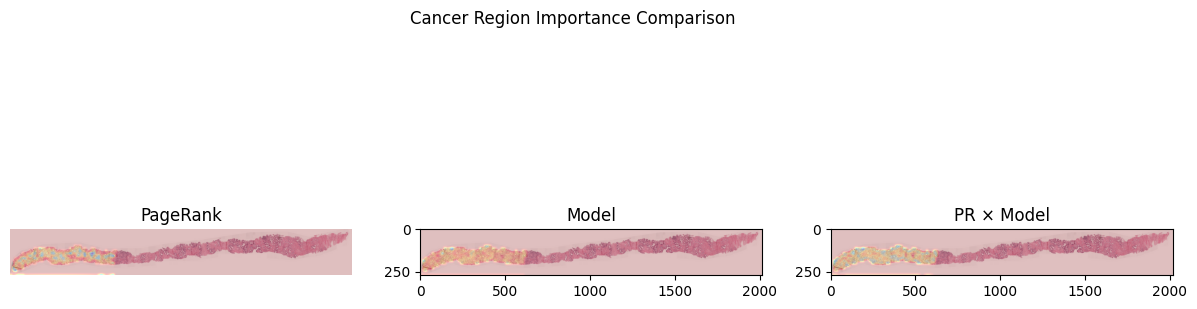

In [8]:
def overlay_three(slide_path, coords, pr, preds, patch_size=224, downsample=32):

    import openslide
    import numpy as np
    import matplotlib.pyplot as plt
    import cv2

    slide = openslide.OpenSlide(slide_path)

    level = slide.get_best_level_for_downsample(downsample)
    w, h = slide.level_dimensions[level]

    base = slide.read_region((0,0), level, (w,h))
    base = np.array(base)[:, :, :3]

    scale = slide.level_downsamples[level]

    def create_overlay(values):

        values = (values - values.min()) / (values.max() - values.min() + 1e-6)

        heatmap = np.zeros((h, w))

        for (x, y), score in zip(coords, values):
            x_s = int(x / scale)
            y_s = int(y / scale)
            p_s = int(patch_size / scale)

            heatmap[y_s:y_s+p_s, x_s:x_s+p_s] = score

        heatmap = cv2.GaussianBlur(heatmap, (31,31), 0)
        heatmap_color = cv2.applyColorMap(
            (heatmap * 255).astype(np.uint8),
            cv2.COLORMAP_JET
        )

        return cv2.addWeighted(base, 0.75, heatmap_color, 0.25, 0)

    pr_overlay = create_overlay(pr)
    model_overlay = create_overlay(preds)
    combined_overlay = create_overlay(pr * preds)

    # plot
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(pr_overlay)
    plt.title("PageRank")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(model_overlay)
    plt.title("Model")

    plt.subplot(1,3,3)
    plt.imshow(combined_overlay)
    plt.title("PR × Model")

    plt.suptitle("Cancer Region Importance Comparison")
    plt.show()
    
overlay_three(test_data[0].path, test_data[0].coords, test_data[0].pr, test_data[0].x.mean(dim=1).cpu().numpy())